<a href="https://colab.research.google.com/github/trialdyk/marchine-learning/blob/main/JJS05/S05_TUGAS1.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# Tugas Lab 1 - kNN pada Dataset Suara (`voice.csv`)

Praktikum Pembelajaran Mesin - JS05 Klasifikasi 1

**Tugas:**
1. Buatlah model klasifikasi dengan menggunakan kNN untuk mengklasifikasikan jenis suara `male` dan `female` pada dataset `voice.csv`.
2. Lakukan eksperimen untuk mencari fitur terbaik. Fitur apa saja yang Anda gunakan untuk mendapatkan hasil terbaik?
3. Dengan fitur terpilih dari tugas 2, tentukan nilai $k$ yang optimal, lengkap dengan grafik dan alasan pemilihannya.


## Persiapan - Load dan Eksplorasi Data

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

LABEL = 'label'   # nama kolom label di voice.csv

data = pd.read_csv('voice.csv')
data.head()

,meanfreq,sd,median,Q25,Q75,IQR,skew,kurt,sp.ent,sfm,...,centroid,meanfun,minfun,maxfun,meandom,mindom,maxdom,dfrange,modindx,label
0,0.059781,0.064241,0.032027,0.015071,0.090193,0.075122,12.863462,274.402906,0.893369,0.491918,...,0.059781,0.084279,0.015702,0.275862,0.007812,0.007812,0.007812,0.000000,0.000000,male
1,0.066009,0.067310,0.040229,0.019414,0.092666,0.073252,22.423285,634.613855,0.892193,0.513724,...,0.066009,0.107937,0.015826,0.250000,0.009014,0.007812,0.054688,0.046875,0.052632,male
2,0.077316,0.083829,0.036718,0.008701,0.131908,0.123207,30.757155,1024.927705,0.846389,0.478905,...,0.077316,0.098706,0.015656,0.271186,0.007990,0.007812,0.015625,0.007812,0.046512,male
3,0.151228,0.072111,0.158011,0.096582,0.207955,0.111374,1.232831,4.177296,0.963322,0.727232,...,0.151228,0.088965,0.017798,0.250000,0.201497,0.007812,0.562500,0.554688,0.247119,male
4,0.135120,0.079146,0.124656,0.078720,0.206045,0.127325,1.101174,4.333713,0.971955,0.783568,...,0.135120,0.106398,0.016931,0.266667,0.712812,0.007812,5.484375,5.476562,0.208274,male


In [2]:
data.info()
print(data[LABEL].value_counts())
data.describe()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 3168 entries, 0 to 3167
Data columns (total 21 columns):
 #   Column    Non-Null Count  Dtype  
---  ------    --------------  -----  
 0   meanfreq  3168 non-null   float64
 1   sd        3168 non-null   float64
 2   median    3168 non-null   float64
 3   Q25       3168 non-null   float64
 4   Q75       3168 non-null   float64
 5   IQR       3168 non-null   float64
 6   skew      3168 non-null   float64
 7   kurt      3168 non-null   float64
 8   sp.ent    3168 non-null   float64
 9   sfm       3168 non-null   float64
 10  mode      3168 non-null   float64
 11  centroid  3168 non-null   float64
 12  meanfun   3168 non-null   float64
 13  minfun    3168 non-null   float64
 14  maxfun    3168 non-null   float64
 15  meandom   3168 non-null   float64
 16  mindom    3168 non-null   float64
 17  maxdom    3168 non-null   float64
 18  dfrange   3168 non-null   float64
 19  modindx   3168 non-null   float64
 20  label     3168 non-null   obje

,meanfreq,sd,median,Q25,Q75,IQR,skew,kurt,sp.ent,sfm,mode,centroid,meanfun,minfun,maxfun,meandom,mindom,maxdom,dfrange,modindx
count,3168.000000,3168.000000,3168.000000,3168.000000,3168.000000,3168.000000,3168.000000,3168.000000,3168.000000,3168.000000,3168.000000,3168.000000,3168.000000,3168.000000,3168.000000,3168.000000,3168.000000,3168.000000,3168.000000,3168.000000
mean,0.180907,0.057126,0.185621,0.140456,0.224765,0.084309,3.140168,36.568461,0.895127,0.408216,0.165282,0.180907,0.142807,0.036802,0.258842,0.829211,0.052647,5.047277,4.994630,0.173752
std,0.029918,0.016652,0.036360,0.048680,0.023639,0.042783,4.240529,134.928661,0.044980,0.177521,0.077203,0.029918,0.032304,0.019220,0.030077,0.525205,0.063299,3.521157,3.520039,0.119454
min,0.039363,0.018363,0.010975,0.000229,0.042946,0.014558,0.141735,2.068455,0.738651,0.036876,0.000000,0.039363,0.055565,0.009775,0.103093,0.007812,0.004883,0.007812,0.000000,0.000000
25%,0.163662,0.041954,0.169593,0.111087,0.208747,0.042560,1.649569,5.669547,0.861811,0.258041,0.118016,0.163662,0.116998,0.018223,0.253968,0.419828,0.007812,2.070312,2.044922,0.099766
50%,0.184838,0.059155,0.190032,0.140286,0.225684,0.094280,2.197101,8.318463,0.901767,0.396335,0.186599,0.184838,0.140519,0.046110,0.271186,0.765795,0.023438,4.992188,4.945312,0.139357
75%,0.199146,0.067020,0.210618,0.175939,0.243660,0.114175,2.931694,13.648905,0.928713,0.533676,0.221104,0.199146,0.169581,0.047904,0.277457,1.177166,0.070312,7.007812,6.992188,0.209183
max,0.251124,0.115273,0.261224,0.247347,0.273469,0.252225,34.725453,1309.612887,0.981997,0.842936,0.280000,0.251124,0.237636,0.204082,0.279114,2.957682,0.458984,21.867188,21.843750,0.932374


Korelasi tiap fitur terhadap label (`male` = 1, `female` = 0) dipakai sebagai gambaran awal fitur mana yang paling berpengaruh.

meanfun     0.833921
IQR         0.618916
Q25         0.511455
sp.ent      0.490552
sd          0.479539
sfm         0.357499
centroid    0.337415
meanfreq    0.337415
median      0.283919
maxdom      0.195657
mindom      0.194974
dfrange     0.192213
meandom     0.191067
mode        0.171775
maxfun      0.166461
minfun      0.136692
kurt        0.087195
Q75         0.066906
skew        0.036627
modindx     0.030801
dtype: float64


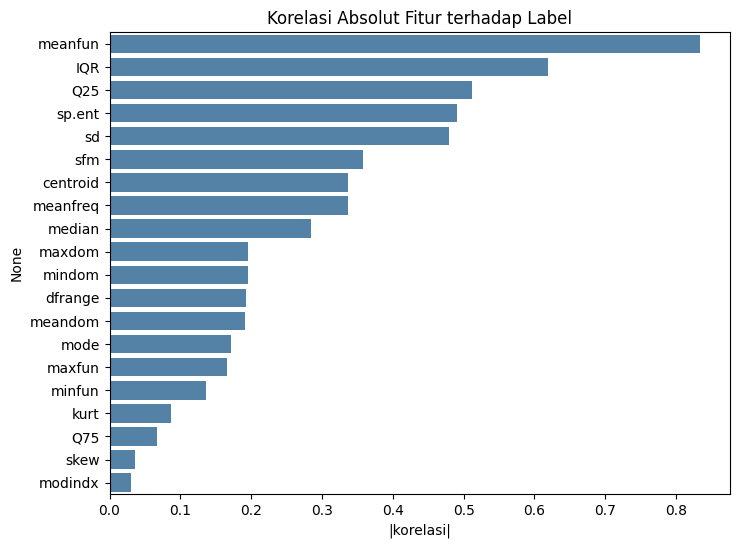

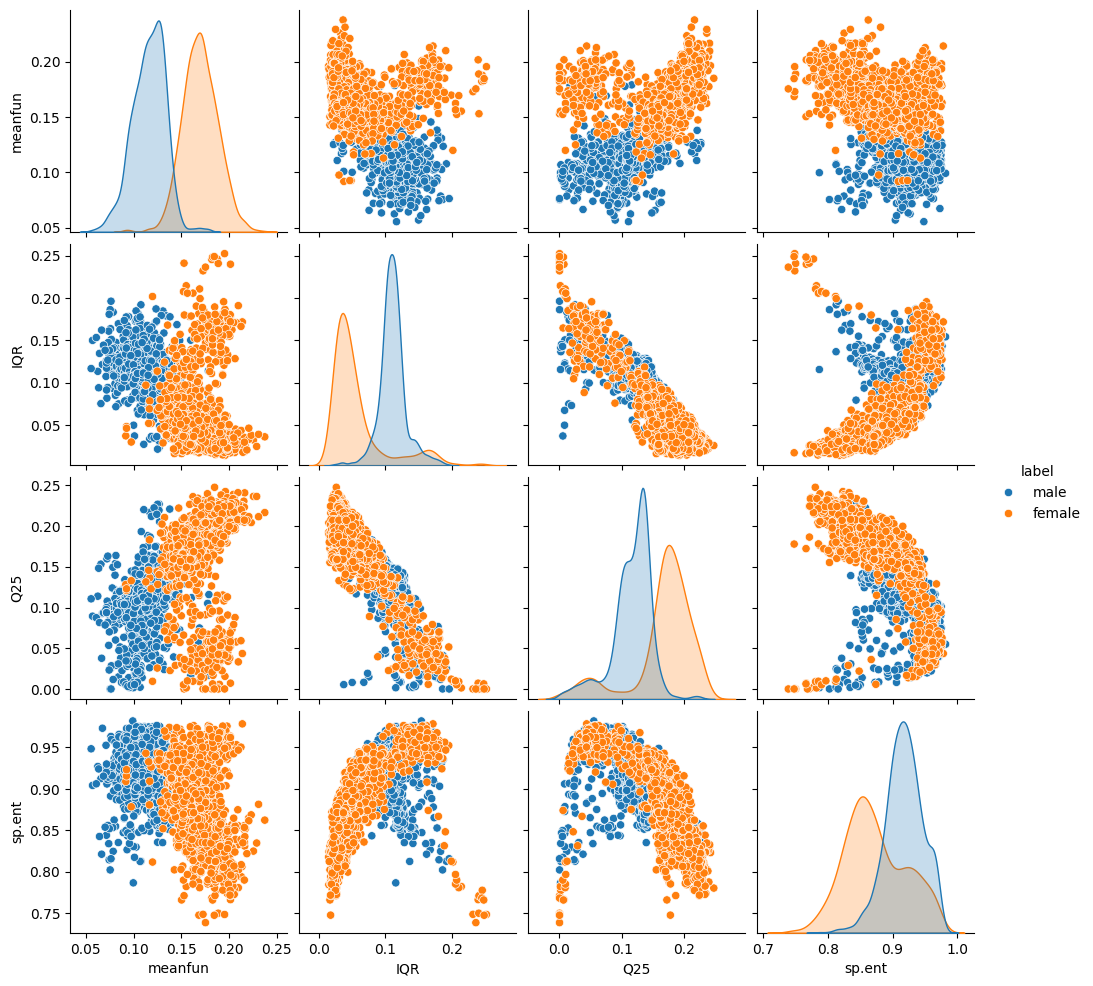

In [3]:
y_num = data[LABEL].map({'male': 1, 'female': 0})
corr = data.drop(columns=LABEL).corrwith(y_num).abs().sort_values(ascending=False)
print(corr)

plt.figure(figsize=(8, 6))
sns.barplot(x=corr.values, y=corr.index, color='steelblue')
plt.title('Korelasi Absolut Fitur terhadap Label')
plt.xlabel('|korelasi|')
plt.show()

# Sebaran 4 fitur dengan korelasi tertinggi
sns.pairplot(data[list(corr.index[:4]) + [LABEL]], hue=LABEL)
plt.show()

## Tugas 1 - Model kNN

Pisahkan fitur dan label, bagi data (70% train, 30% test), lakukan standardisasi, lalu latih kNN dengan semua fitur sebagai baseline.

In [4]:
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.neighbors import KNeighborsClassifier
from sklearn.metrics import accuracy_score, confusion_matrix, classification_report

X = data.drop(columns=LABEL)
y = data[LABEL]

# Split data (70% train, 30% test)
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.3, random_state=42, stratify=y
)

# Standardisasi
scaler = StandardScaler()
X_train_s = scaler.fit_transform(X_train)
X_test_s = scaler.transform(X_test)

# Model kNN baseline (k = 3, semua fitur)
knn = KNeighborsClassifier(n_neighbors=3)
knn.fit(X_train_s, y_train)

y_pred = knn.predict(X_test_s)
print("Akurasi:", accuracy_score(y_test, y_pred))
print("Confusion Matrix:\n", confusion_matrix(y_test, y_pred))
print("Laporan Klasifikasi:\n", classification_report(y_test, y_pred))

Akurasi: 0.9737118822292324
Confusion Matrix:
 [[462  14]
 [ 11 464]]
Laporan Klasifikasi:
               precision    recall  f1-score   support

      female       0.98      0.97      0.97       476
        male       0.97      0.98      0.97       475

    accuracy                           0.97       951
   macro avg       0.97      0.97      0.97       951
weighted avg       0.97      0.97      0.97       951



## Tugas 2 - Eksperimen Pemilihan Fitur

Fitur diurutkan berdasarkan korelasi absolut terhadap label, lalu ditambahkan satu per satu (top-1, top-2, ..., semua fitur). Setiap kombinasi dievaluasi dengan **cross-validation 5-fold pada data training** (standardisasi berada di dalam pipeline sehingga tidak ada kebocoran data), dan akurasi data test ditampilkan sebagai pembanding. Pemilihan fitur terbaik berdasarkan akurasi cross-validation, bukan data test.

In [5]:
from sklearn.pipeline import make_pipeline
from sklearn.model_selection import cross_val_score

def evaluasi(fitur, k=3):
    model = make_pipeline(StandardScaler(), KNeighborsClassifier(n_neighbors=k))
    cv = cross_val_score(model, X_train[fitur], y_train, cv=5).mean()
    model.fit(X_train[fitur], y_train)
    test = model.score(X_test[fitur], y_test)
    return cv, test

ranking = list(corr.index)
hasil = []
for n in range(1, len(ranking) + 1):
    fitur = ranking[:n]
    cv, test = evaluasi(fitur)
    hasil.append({
        'jumlah_fitur': n,
        'fitur_ditambahkan': ranking[n - 1],
        'akurasi_cv': cv,
        'akurasi_test': test
    })

df_hasil = pd.DataFrame(hasil)
df_hasil

,jumlah_fitur,fitur_ditambahkan,akurasi_cv,akurasi_test
0,1,meanfun,0.940460,0.952681
1,2,IQR,0.963016,0.974763
2,3,Q25,0.968419,0.975815
3,4,sp.ent,0.971126,0.975815
4,5,sd,0.972933,0.985279
5,6,sfm,0.975189,0.987382
6,7,centroid,0.975189,0.983176
7,8,meanfreq,0.974286,0.983176
8,9,median,0.974741,0.984227
9,10,maxdom,0.976541,0.982124


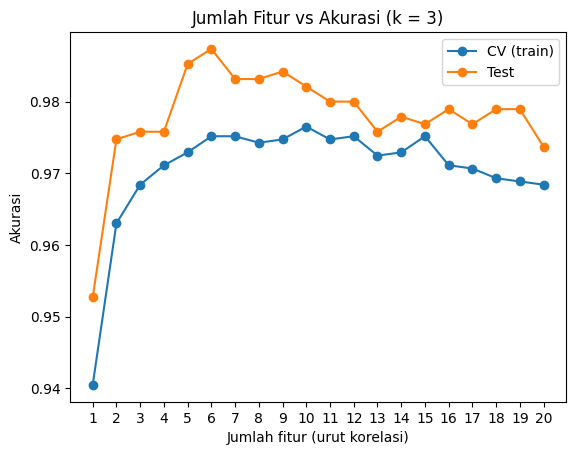

Jumlah fitur terbaik: 10
Fitur terpilih: ['meanfun', 'IQR', 'Q25', 'sp.ent', 'sd', 'sfm', 'centroid', 'meanfreq', 'median', 'maxdom']


In [6]:
plt.plot(df_hasil['jumlah_fitur'], df_hasil['akurasi_cv'], marker='o', label='CV (train)')
plt.plot(df_hasil['jumlah_fitur'], df_hasil['akurasi_test'], marker='o', label='Test')
plt.title('Jumlah Fitur vs Akurasi (k = 3)')
plt.xlabel('Jumlah fitur (urut korelasi)')
plt.ylabel('Akurasi')
plt.xticks(df_hasil['jumlah_fitur'])
plt.legend()
plt.show()

# Fitur terbaik = jumlah fitur dengan akurasi CV tertinggi (jika sama, ambil yang paling sedikit)
best_n = int(df_hasil.loc[df_hasil['akurasi_cv'].idxmax(), 'jumlah_fitur'])
best_features = ranking[:best_n]
print("Jumlah fitur terbaik:", best_n)
print("Fitur terpilih:", best_features)

### Jawaban Tugas 2

**Fitur yang digunakan untuk hasil terbaik:** _(isi dengan fitur terpilih dari output di atas)_

**Alasan / analisis:** _(jelaskan, misalnya: bagaimana akurasi berubah saat fitur ditambah, apakah semua fitur justru menurunkan akurasi, dan fitur mana yang paling berpengaruh)_

## Tugas 3 - Nilai $k$ Optimal

Dengan fitur terpilih, evaluasi nilai $k$ dari 1 sampai 30. Akurasi dihitung pada data training, cross-validation, dan data test.

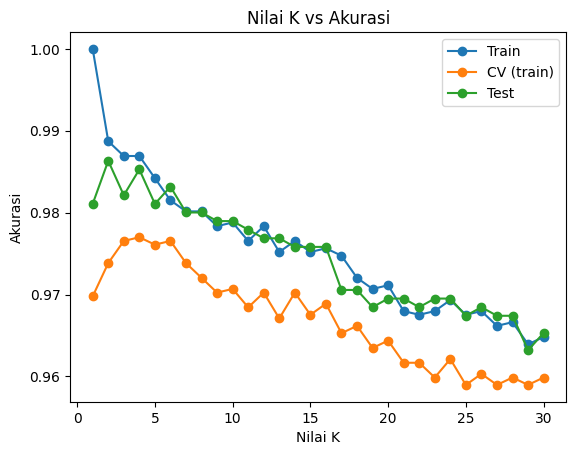

k optimal: 4
Akurasi CV  : 0.9769955056636773
Akurasi test: 0.9852786540483701


In [7]:
ks = list(range(1, 31))
acc_train, acc_cv, acc_test = [], [], []

for k in ks:
    model = make_pipeline(StandardScaler(), KNeighborsClassifier(n_neighbors=k))
    acc_cv.append(cross_val_score(model, X_train[best_features], y_train, cv=5).mean())
    model.fit(X_train[best_features], y_train)
    acc_train.append(model.score(X_train[best_features], y_train))
    acc_test.append(model.score(X_test[best_features], y_test))

plt.plot(ks, acc_train, marker='o', label='Train')
plt.plot(ks, acc_cv, marker='o', label='CV (train)')
plt.plot(ks, acc_test, marker='o', label='Test')
plt.title('Nilai K vs Akurasi')
plt.xlabel('Nilai K')
plt.ylabel('Akurasi')
plt.legend()
plt.show()

# k optimal = akurasi CV tertinggi (jika sama, ambil k terkecil)
best_k = ks[int(np.argmax(acc_cv))]
print("k optimal:", best_k)
print("Akurasi CV  :", acc_cv[best_k - 1])
print("Akurasi test:", acc_test[best_k - 1])

### Jawaban Tugas 3

**Nilai $k$ optimal:** _(isi dengan `best_k` dari output di atas)_

**Alasan pemilihan:** _(jelaskan berdasarkan grafik, misalnya: pada $k$ berapa akurasi CV paling tinggi/stabil, bagaimana kecenderungan overfitting pada $k$ kecil dan underfitting pada $k$ besar, serta kedekatan akurasi train dan test)_

## Evaluasi Akhir

Model akhir memakai fitur terpilih dan $k$ optimal.

In [8]:
final_model = make_pipeline(StandardScaler(), KNeighborsClassifier(n_neighbors=best_k))
final_model.fit(X_train[best_features], y_train)
y_pred_final = final_model.predict(X_test[best_features])

print("Fitur :", best_features)
print("k     :", best_k)
print("Akurasi:", accuracy_score(y_test, y_pred_final))
print("Confusion Matrix:\n", confusion_matrix(y_test, y_pred_final))
print("Laporan Klasifikasi:\n", classification_report(y_test, y_pred_final))

Fitur : ['meanfun', 'IQR', 'Q25', 'sp.ent', 'sd', 'sfm', 'centroid', 'meanfreq', 'median', 'maxdom']
k     : 4
Akurasi: 0.9852786540483701
Confusion Matrix:
 [[470   6]
 [  8 467]]
Laporan Klasifikasi:
               precision    recall  f1-score   support

      female       0.98      0.99      0.99       476
        male       0.99      0.98      0.99       475

    accuracy                           0.99       951
   macro avg       0.99      0.99      0.99       951
weighted avg       0.99      0.99      0.99       951

